# Three-Lens IL System: DAC Calibration and Forward Prediction

This notebook calibrates the intermediate-lens (IL) system of a TEM from raw
DAC hex tables, then forward-predicts lens currents for arbitrary magnification
or camera length.

## Physical setup

Three intermediate lenses (IL1, IL2, IL3) sit between the objective and the
projector.  The microscope operates in two modes that share the same IL optics
but differ in object-plane distance $d_1$:

| Mode | Target quantity | Relation |
|------|----------------|----------|
| **Imaging** | system magnification $M_\text{sys}$ | $M_\text{sys} = M_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |
| **Camera length** | $\text{CL}$ [mm] | $\text{CL} = f_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |

Scale factors $s_\text{img}$, $s_\text{cam}$ are fitted so no a-priori knowledge
of $M_\text{obj}$, $M_\text{proj}$, or $f_\text{obj}$ is needed.

Rc at 200 kV = 5.301506e-04 rad/AT
Imaging:  14 points,  mag 30000..600000
Camera:   15 points,  CL 80..2000 mm


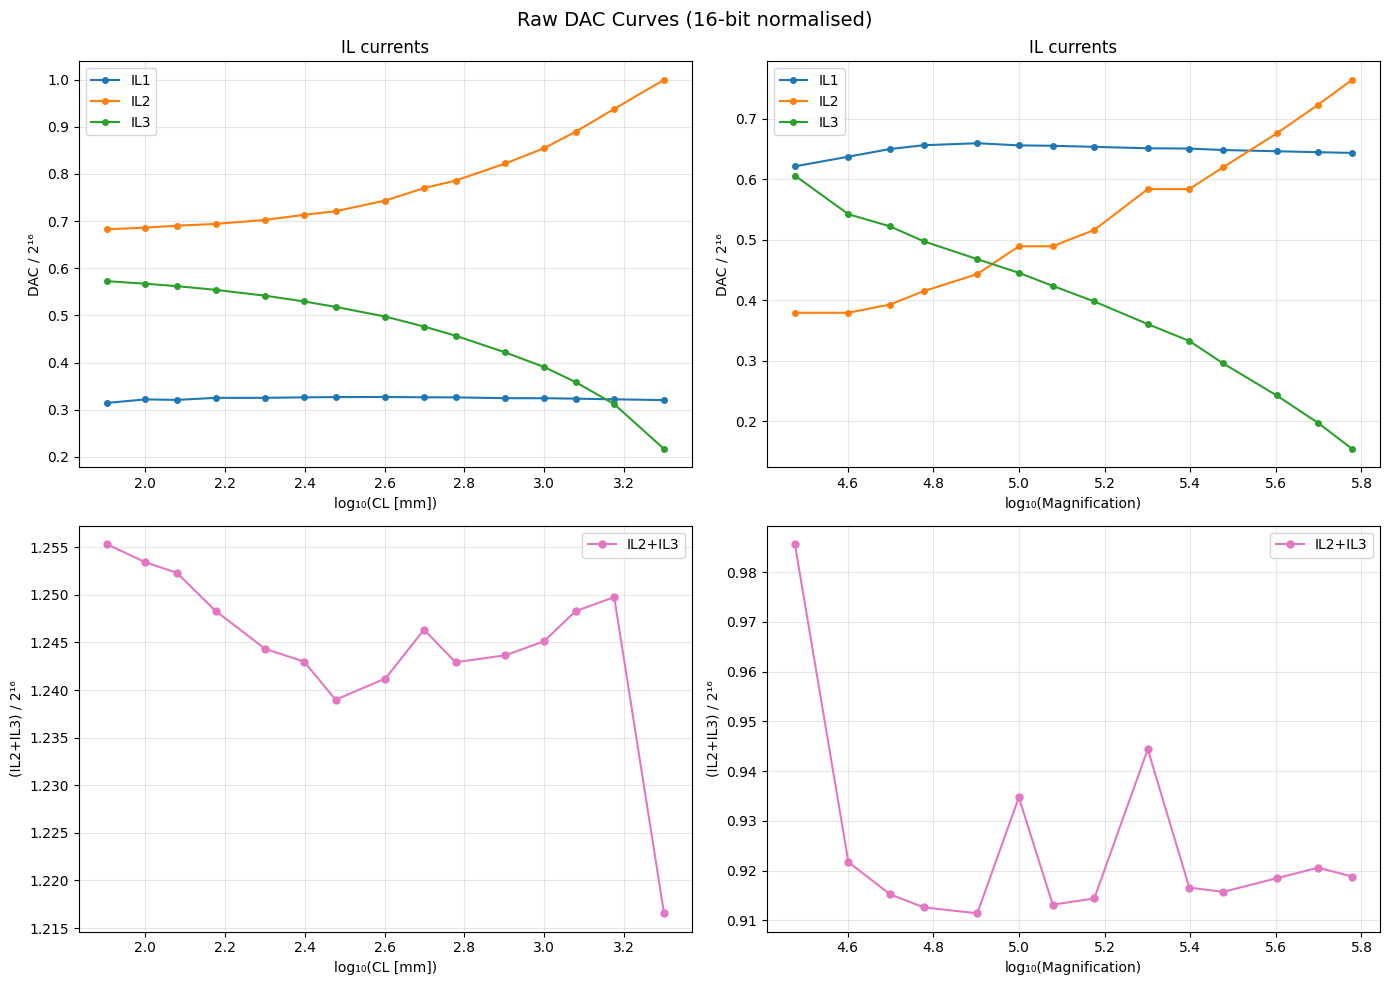

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Raw DAC hex tables (from microscope service menu) ====

CAMERA_LENGTH_RAW_DAC_HEX = {
    "80":   {"OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5078","IL2":"0xaec1","IL3":"0x929c","PL1":"0xfa00"},
    "100":  {"OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5265","IL2":"0xafa9","IL3":"0x9137","PL1":"0xfa00"},
    "120":  {"OM2":"0x0","IL1":"0x5221","IL2":"0xb0b6","IL3":"0x8fe1","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "150":  {"OM2":"0x0","IL1":"0x533e","IL2":"0xb1ad","IL3":"0x8de4","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "200":  {"IL2":"0xb3dc","IL3":"0x8aaf","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x533e"},
    "250":  {"OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5383","IL2":"0xb69f","IL3":"0x8796","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a"},
    "300":  {"OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x53a9","IL2":"0xb88f","IL3":"0x849f","PL1":"0xfa00","OLc":"0xb2fa"},
    "400":  {"IL1":"0x53b3","IL2":"0xbe63","IL3":"0x7f5d","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0"},
    "500":  {"OM2":"0x0","IL1":"0x538b","IL2":"0xc51d","IL3":"0x79f3","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "600":  {"OM2":"0x0","IL1":"0x5381","IL2":"0xc930","IL3":"0x7500","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "800":  {"IL1":"0x530b","IL2":"0xd280","IL3":"0x6be0","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0"},
    "1000": {"IL2":"0xdac0","IL3":"0x6400","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x530b"},
    "1200": {"OM2":"0x0","IL1":"0x52cb","IL2":"0xe3c0","IL3":"0x5bd0","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "1500": {"IL2":"0xf020","IL3":"0x4fd0","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5271"},
    "2000": {"OM2":"0x0","IL1":"0x5208","IL2":"0xfff0","IL3":"0x3780","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
}

IMAGING_MODE_RAW_DAC_HEX = {
    "30000":  {"IL1":"0x9f22","IL2":"0x611e","IL3":"0x9b35","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "40000":  {"IL1":"0xa336","IL2":"0x611e","IL3":"0x8ad8","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "50000":  {"IL1":"0xa674","IL2":"0x6498","IL3":"0x85b7","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "60000":  {"IL1":"0xa810","IL2":"0x6a48","IL3":"0x7f59","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "80000":  {"IL1":"0xa8ea","IL2":"0x7182","IL3":"0x77d2","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "100000": {"IL1":"0xa800","IL2":"0x7d46","IL3":"0x7205","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "120000": {"IL1":"0xa7d4","IL2":"0x7d46","IL3":"0x6c7f","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "150000": {"IL1":"0xa761","IL2":"0x8431","IL3":"0x65e6","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "200000": {"IL1":"0xa6c5","IL2":"0x957b","IL3":"0x5c4a","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "250000": {"IL1":"0xa6a8","IL2":"0x957b","IL3":"0x552b","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "300000": {"IL1":"0xa608","IL2":"0x9ec6","IL3":"0x4ba8","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "400000": {"IL1":"0xa584","IL2":"0xad0c","IL3":"0x3e16","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "500000": {"IL1":"0xa51d","IL2":"0xb944","IL3":"0x3268","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "600000": {"IL1":"0xa4d0","IL2":"0xc3c7","IL3":"0x2771","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
}

# ==== Parse hex -> numeric arrays ====

DAC_FULL_SCALE = float(2 ** 16)

def parse_hex_table(raw, primary_axis_name):
    primary_values = sorted(int(key) for key in raw)
    data = {
        primary_axis_name: np.array(primary_values, dtype=float),
        f"log_{primary_axis_name}": np.log10(primary_values),
    }
    for lens_name in next(iter(raw.values())):
        data[lens_name] = np.array(
            [int(raw[str(v)][lens_name], 16) for v in primary_values], dtype=float,
        )
    return data

def scale_to_full_dac(values):
    return np.asarray(values, dtype=float) / DAC_FULL_SCALE

camera_length_dac = parse_hex_table(CAMERA_LENGTH_RAW_DAC_HEX, "camera_length_mm")
imaging_mode_dac  = parse_hex_table(IMAGING_MODE_RAW_DAC_HEX, "magnification")

# ==== Physical constants ====

M_PROJ = -100.0         # projector magnification (sign = image inversion)
I_MAX  = 5.0            # DAC full-scale current [A]
N_TURNS = np.array([1000, 1000, 1000])   # winding turns per IL lens

# Larmor rotation constant Rc at 200 kV:  Rc = e*mu0 / (2*me*v_rel)
U_ACCEL = 200e3
_e, _me, _c = 1.602176634e-19, 9.1093837015e-31, 299792458.0
_mu0 = 1.25663706212e-6
_gamma = 1.0 + _e * U_ACCEL / (_me * _c**2)
_v = _c * np.sqrt(1.0 - 1.0 / _gamma**2)
RC = float(_e * _mu0 / (2.0 * _me * _v))
print(f"Rc at {U_ACCEL/1e3:.0f} kV = {RC:.6e} rad/AT")

# ==== Normalised DAC reference arrays ====

mags_ref = np.array(sorted(int(k) for k in IMAGING_MODE_RAW_DAC_HEX), dtype=float)
x1_ref = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL1"], 16) for m in mags_ref], dtype=float) / 65535.0
x2_ref = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL2"], 16) for m in mags_ref], dtype=float) / 65535.0
x3_ref = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL3"], 16) for m in mags_ref], dtype=float) / 65535.0

cl_ref    = np.asarray(camera_length_dac["camera_length_mm"], dtype=float)
x1_cl_ref = scale_to_full_dac(camera_length_dac["IL1"])
x2_cl_ref = scale_to_full_dac(camera_length_dac["IL2"])
x3_cl_ref = scale_to_full_dac(camera_length_dac["IL3"])

print(f"Imaging:  {len(mags_ref)} points,  mag {mags_ref.min():.0f}..{mags_ref.max():.0f}")
print(f"Camera:   {len(cl_ref)} points,  CL {cl_ref.min():.0f}..{cl_ref.max():.0f} mm")

# ==== Visualise raw DAC curves ====

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (data, xk, xlabel) in enumerate([
    (camera_length_dac, "log_camera_length_mm", "log₁₀(CL [mm])"),
    (imaging_mode_dac,  "log_magnification",    "log₁₀(Magnification)"),
]):
    # Top row: IL1, IL2, IL3
    ax = axes[0, col]
    for lens, c in zip(["IL1","IL2","IL3"], ["C0","C1","C2"]):
        ax.plot(data[xk], scale_to_full_dac(data[lens]), "o-", label=lens, color=c, ms=4)
    ax.set_ylabel("DAC / 2¹⁶"); ax.set_title(f"IL currents"); ax.legend(); ax.grid(True, alpha=0.3)

    # Bottom row: zoom-pair sum IL2+IL3
    ax = axes[1, col]
    ax.plot(data[xk], scale_to_full_dac(data["IL2"] + data["IL3"]), "o-", color="C6", ms=5, label="IL2+IL3")
    ax.set_ylabel("(IL2+IL3) / 2¹⁶"); ax.set_xlabel(xlabel); ax.legend(); ax.grid(True, alpha=0.3)

axes[0, 0].set_xlabel("log₁₀(CL [mm])"); axes[0, 1].set_xlabel("log₁₀(Magnification)")
fig.suptitle("Raw DAC Curves (16-bit normalised)", fontsize=14)
fig.tight_layout()
plt.show()

## Analytical solver

### Magnetic lens optics recap

The optical power (inverse focal length) of a magnetic round lens is

$$\phi \;=\; \frac{e}{8\,m_e\,U^*}\;\int_{-\infty}^{\infty} B_z^2(z)\,dz$$

where $U^* = U(1 + eU/2m_ec^2)$ is the relativistic accelerating potential.
Since $B_z \propto NI$, we get $\phi \propto (NI)^2$ with a proportionality
constant that depends only on **geometry** (bore, gap, pole pieces):

$$\phi_k \;=\; \underbrace{\alpha_\text{geom,k}\, N_k^2\, I_\text{MAX}^2}_{\displaystyle \alpha_k}\; x_k^2$$

The code fits the lumped $\alpha_k$ for each lens.  If the three IL lenses
share the same bore/gap design, their $\alpha_k$ differ only through winding
turns: $N_k/N_1 = \sqrt{\alpha_k/\alpha_1}$.  This is tested as a diagnostic
after fitting.

### Transfer-matrix polynomials $A$ and $B$

Each thin lens and drift is a $2{\times}2$ matrix:

$$P(d) = \begin{pmatrix}1 & d \\ 0 & 1\end{pmatrix}, \qquad
L(\phi) = \begin{pmatrix}1 & 0 \\ -\phi & 1\end{pmatrix}$$

The full IL transfer matrix is their product:

$$M = P(d_4)\, L(\phi_3)\, P(d_3)\, L(\phi_2)\, P(d_2)\, L(\phi_1)\, P(d_1)$$

Multiplying out, $A = M_{00}$ and $B = M_{01}$ are both **multilinear** in
$(\phi_1, \phi_2, \phi_3)$ — each variable appears at most to first power.
Written out in full:

$$A = 1 - (d_2{+}d_3{+}d_4)\,\phi_1 - (d_3{+}d_4)\,\phi_2 - d_4\,\phi_3$$
$$\quad + d_2(d_3{+}d_4)\,\phi_1\phi_2 + (d_2{+}d_3)d_4\,\phi_1\phi_3 + d_3 d_4\,\phi_2\phi_3 - d_2 d_3 d_4\,\phi_1\phi_2\phi_3$$

$$B = (d_1{+}d_2{+}d_3{+}d_4) - d_1(d_2{+}d_3{+}d_4)\,\phi_1 - (d_1{+}d_2)(d_3{+}d_4)\,\phi_2 - (d_1{+}d_2{+}d_3)d_4\,\phi_3$$
$$\quad + d_1 d_2(d_3{+}d_4)\,\phi_1\phi_2 + d_1(d_2{+}d_3)d_4\,\phi_1\phi_3 + (d_1{+}d_2)d_3 d_4\,\phi_2\phi_3 - d_1 d_2 d_3 d_4\,\phi_1\phi_2\phi_3$$

The key observation is easiest to see by isolating lens 1 and everything after
it.  Define

$$M_\text{rest} \;=\; P(d_4)\,L(\phi_3)\,P(d_3)\,L(\phi_2)\,P(d_2)$$

so that

$$M = M_\text{rest} \, L(\phi_1) \, P(d_1).$$

Physically, $M_\text{rest}$ is the transfer matrix for the part of the column
**after lens 1**: drift $d_2$, lens 2, drift $d_3$, lens 3, and drift $d_4$ to
the image plane.  It depends on $(\phi_2, \phi_3)$ but not on $\phi_1$.

If we write

$$M_\text{rest} = \begin{pmatrix} r_{11} & r_{12} \\ r_{21} & r_{22} \end{pmatrix}$$

then

$$L(\phi_1)P(d_1) = \begin{pmatrix} 1 & d_1 \\ -\phi_1 & 1 - d_1\phi_1 \end{pmatrix}$$

and multiplying the top row gives

$$A = M_{00} = r_{11} - r_{12}\phi_1$$
$$B = M_{01} = r_{11}d_1 + r_{12}(1 - d_1\phi_1).$$

So if we rename

$$a = r_{11}, \qquad b = r_{12},$$

then

$$A = a - b\,\phi_1, \qquad B = a\,d_1 + b\,(1 - d_1\,\phi_1).$$

Now the structure is obvious: $a$ and $b$ depend only on $(\phi_2, \phi_3)$,
and the coefficient of $\phi_1$ in $B$ is exactly $d_1$ times the coefficient
of $\phi_1$ in $A$.

### Eliminating $\phi_1$: why $B = 0$ and $A = m$ reduce to one equation in $(\phi_2, \phi_3)$

From $A = m$: $\;\phi_1 = (a - m)/b$.  Substituting into $B = 0$:

$$a\,d_1 + b - d_1\,b\,\frac{a - m}{b} = 0 \;\;\Longrightarrow\;\; a\,d_1 + b - d_1(a - m) = 0 \;\;\Longrightarrow\;\; b + d_1\, m = 0$$

The $\phi_1$ cancels completely.  The combined constraint **$B = 0$ and $A = m$**
collapses to a single equation involving only the downstream optics encoded in
$M_\text{rest}$:

$$M_\text{rest}[0,1] \;=\; -d_1\, m.$$

### Why the result is linear in $\phi_2$  (and gives a closed-form $\phi_2$)

$M_\text{rest}[0,1]$ is a polynomial in $(\phi_2, \phi_3)$ that is multilinear
— degree 1 in each.  After expanding:

$$M_\text{rest}[0,1] = (d_2{+}d_3{+}d_4) - d_2(d_3{+}d_4)\,\phi_2 - (d_2{+}d_3)d_4\,\phi_3 + d_2 d_3 d_4\,\phi_2\phi_3$$

Setting this equal to $-d_1 m$ and collecting the $\phi_2$ terms:

$$\phi_2\,\bigl[d_2\bigl((d_3{+}d_4) - d_3 d_4\,\phi_3\bigr)\bigr] = d_1\,m + (d_2{+}d_3{+}d_4) - (d_2{+}d_3)d_4\,\phi_3$$

This is **linear in $\phi_2$** — a single division gives the closed-form
solution `phi2_exact` in the code.

### Why $A = m$ then gives $\phi_1$ directly

With $\phi_2$ and $\phi_3$ now both known numbers, $A$ is a polynomial that is
linear in $\phi_1$ (multilinear means degree $\leq 1$ in $\phi_1$):

$$A = \underbrace{(1 - (d_3{+}d_4)\phi_2 - d_4\phi_3 + d_3 d_4\phi_2\phi_3)}_{A^{(0)}} \;+\; \phi_1\,\underbrace{(-(d_2{+}d_3{+}d_4) + d_2(d_3{+}d_4)\phi_2 + (d_2{+}d_3)d_4\phi_3 - d_2 d_3 d_4\phi_2\phi_3)}_{A^{(1)}}$$

So $\phi_1 = (m - A^{(0)}) / A^{(1)}$ — again a single division, implemented
as `phi1_exact` in the code.

### How the fit works (inverse step)

We know the **data**: for each magnification/camera-length setting, the
microscope DAC tables give $(x_1, x_2, x_3)$.  We also know the **targets**:
$A = m$ (the desired IL magnification) and $B = 0$ (focused image).

The **unknowns** are the 9 geometry/scale parameters.  We plug each data
point's $\phi_k = \alpha_k x_k^2$ into the $A$ and $B$ polynomials, form
residuals, and run `scipy.optimize.least_squares` (plus soft CAD priors).

### How the curves are generated (forward step)

Once the 9 parameters are known, we reverse the problem — given a desired $m$,
find $(x_1, x_2, x_3)$:

1. **Pick** a trial $x_3$ (i.e.\ $\phi_3 = \alpha_3 x_3^2$)
2. **Solve** for $\phi_2$ from the combined $B{=}0$, $A{=}m$ constraint
   (one division, as derived above)
3. **Solve** for $\phi_1$ from $A = m$ (one division)
4. **Convert** back: $x_k = \sqrt{\phi_k / \alpha_k}$, reject if any $x_k > 1$

One degree of freedom remains ($x_3$).  It is fixed by the **rotation
constraint**: $x_1 + x_2 + x_3 = r$ (constant), solved as a 1-D root find.

### Fit parameters (9 total)

| Parameter | Description |
|-----------|-------------|
| $d_1^{\text{img}},\; d_1^{\text{cam}}$ | Object distance (differs between modes) |
| $d_2,\; d_4$ | Shared inter-lens distances | 
| $\alpha_1,\;\alpha_2,\;\alpha_3$ | Current-to-power constants (absorb geometry + turns + $I_\text{MAX}$) |
| $s_\text{img},\; s_\text{cam}$ | Scale factors (absorb $M_\text{obj} M_\text{proj}$ and $f_\text{obj} M_\text{proj}$) |

Rotation invariant  r = x1+x2+x3:
  Imaging: 1.5730 +/- 0.0138
  Camera:  1.5683 +/- 0.0087

CAD priors  (d3=62.5 mm):
  d2=1.233  d4=0.833  d1_img=0.200  d1_cam=3.200

Fitting: 4 signs × 13 starts × 3 img-weights × 2 methods ...
Done in 21.0s  |  signs=(+1,+1)  w_img=1.0  cost=0.456403

Distances (d3=1=62.5 mm):
  d1_img  = 0.2112  (CAD 0.200, +0.4σ)
  d1_cam  = 2.1723  (CAD 3.200, -2.1σ)
  d2      = 1.1870  (CAD 1.233, -0.3σ)
  d4      = 0.8323  (CAD 0.833, -0.0σ)
  alpha   = [13.1786, 15.6901, 6.6768]
  s_img   = 1.1725e-04   →  M_obj·M_proj = 8529.0
  s_cam   = 5.8749e-03   →  f_obj = 1.702 mm

Implied turns ratios  γ_k = N_k/N_1 = √(α_k/α_1):
  γ = [1.0000, 1.0911, 0.7118]
  If N_1=1000:  N = [1000, 1091, 712]

Larmor rotation  θ = Rc·I_MAX·Σ(Nk·xk)   (I_MAX=5.0 A, N=[1000,1000,1000]):
  Imaging: 238.9° ± 2.1°
  Camera:  238.2° ± 1.3°
  (with implied N):  Imaging 229.1°  Camera 228.6°

Rotation-invariant quality  (lower CV% = more constant):
  Equal wt:   img CV=0.88%  cam CV=0.55

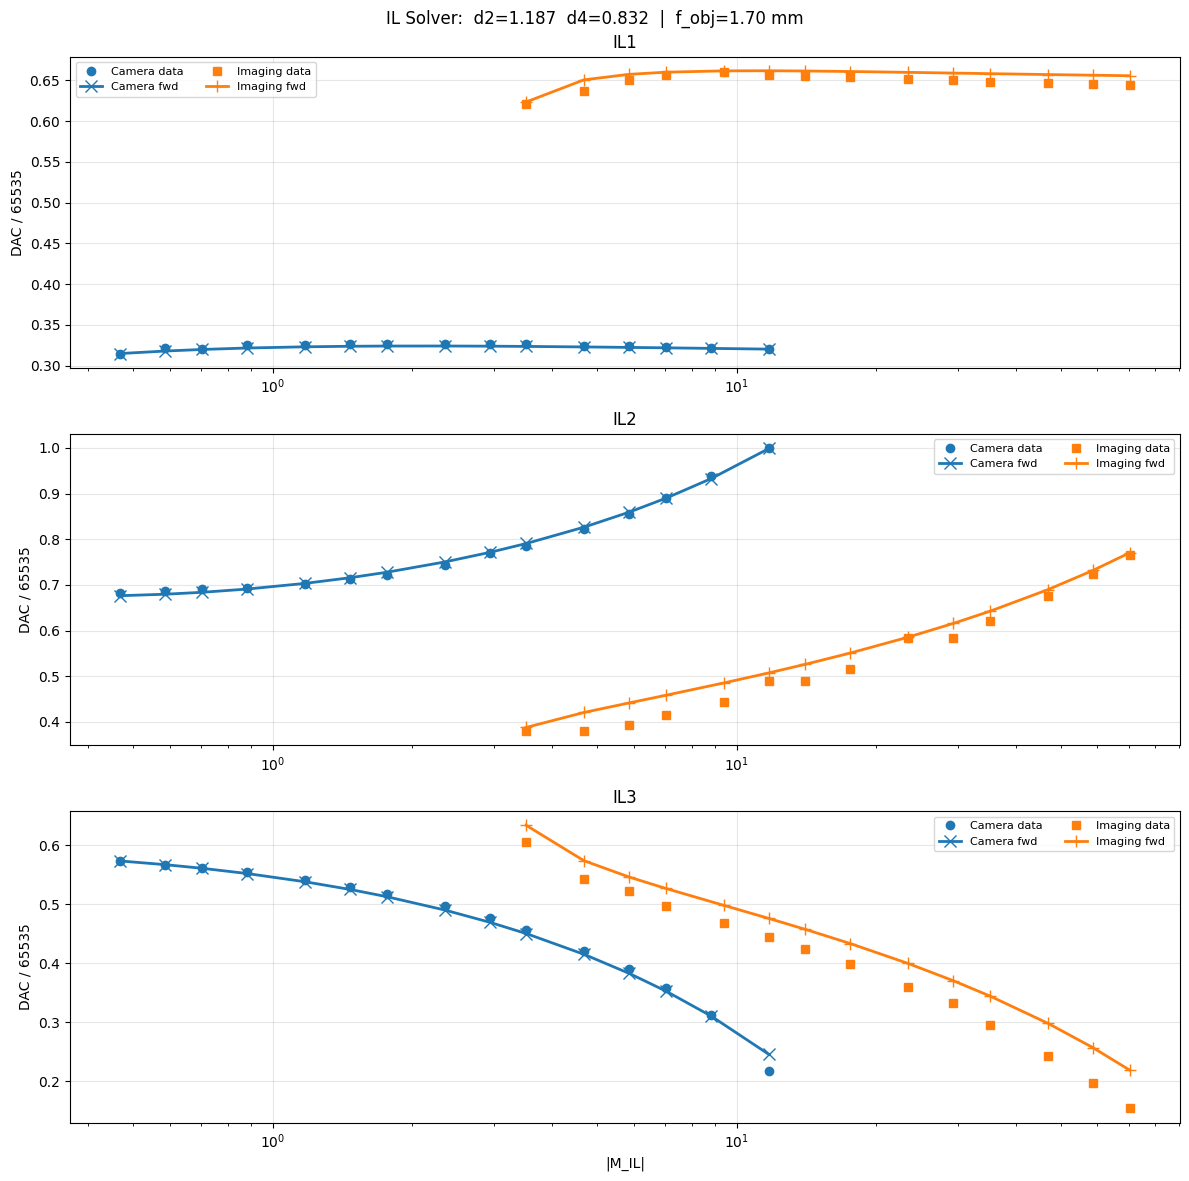


RMSE (forward vs data):
  IL1: img=0.00835  cam=0.00222
  IL2: img=0.02956  cam=0.00466
  IL3: img=0.04127  cam=0.00884
  Overall: 0.02107  (29/29 points)


In [37]:
from scipy.optimize import least_squares, brentq
import time

# ── Transfer-matrix polynomials A = M[0,0], B = M[0,1] ──────────────

def A_poly(d, p):
    d1, d2, d3, d4 = d
    p1, p2, p3 = p
    return (1.0
            - (d2+d3+d4)*p1 - (d3+d4)*p2 - d4*p3
            + d2*(d3+d4)*p1*p2 + (d2+d3)*d4*p1*p3 + d3*d4*p2*p3
            - d2*d3*d4*p1*p2*p3)

def B_poly(d, p):
    d1, d2, d3, d4 = d
    p1, p2, p3 = p
    return ((d1+d2+d3+d4)
            - d1*(d2+d3+d4)*p1 - (d1+d2)*(d3+d4)*p2 - (d1+d2+d3)*d4*p3
            + d1*d2*(d3+d4)*p1*p2 + d1*(d2+d3)*d4*p1*p3 + (d1+d2)*d3*d4*p2*p3
            - d1*d2*d3*d4*p1*p2*p3)

# ── Rotation invariant from data ─────────────────────────────────────

w = np.ones(3)                            # equal turns → equal weights
r_img_vals = x1_ref + x2_ref + x3_ref
r_cam_vals = x1_cl_ref + x2_cl_ref + x3_cl_ref
print(f"Rotation invariant  r = x1+x2+x3:")
print(f"  Imaging: {np.mean(r_img_vals):.4f} +/- {np.std(r_img_vals):.4f}")
print(f"  Camera:  {np.mean(r_cam_vals):.4f} +/- {np.std(r_cam_vals):.4f}")

# ── CAD priors (from pixel measurements in measure_microscope_geometry) ──
#    Scale bar: 96 px = 200 mm;  d3 = IL2→IL3 = 30 px → reference length
_px_mm = 200.0 / (624 - 528)
_d3_mm = (739 - 709) * _px_mm
CAD_D2  = (709 - 672) * _px_mm / _d3_mm   # IL1→IL2
CAD_D4  = (764 - 739) * _px_mm / _d3_mm   # IL3→PL1
CAD_D1I = (672 - 666) * _px_mm / _d3_mm   # SAA→IL1  (imaging object)
CAD_D1C = (672 - 576) * _px_mm / _d3_mm   # ObjPost→IL1  (diffraction object)
CAD_SIGMA = 0.15   # fractional 1-sigma (~2-3 px uncertainty)
W_CAD   = 1.0      # CAD prior weight

# f_obj soft prior: |M_proj|·f_obj ≈ 1/s_cam, expect f_obj ∈ [1, 4] mm
F_OBJ_MIN_MM, F_OBJ_MAX_MM = 1.0, 4.0
W_FOBJ = 0.1
W_IL2  = 1.0       # IL2 emphasis in forward branch selection

print(f"\nCAD priors  (d3={_d3_mm:.1f} mm):")
print(f"  d2={CAD_D2:.3f}  d4={CAD_D4:.3f}  d1_img={CAD_D1I:.3f}  d1_cam={CAD_D1C:.3f}")

# ── Inverse fit ──────────────────────────────────────────────────────
# 9 parameters: [d1_img, d1_cam, d2, d4,
#                log(α1), log(α2), log(α3), log(s_img), log(s_cam)]

x_img = np.array([x1_ref, x2_ref, x3_ref])
x_cam = np.array([x1_cl_ref, x2_cl_ref, x3_cl_ref])

def make_residual_fn(si, sc, w_img=1.0):
    """Build residual function.  w_img upweights imaging residuals."""
    def fn(p):
        d1i, d1c, d2, d4 = p[:4]
        alpha = np.exp(p[4:7])
        s_i, s_c = np.exp(p[7]), np.exp(p[8])
        d_i = np.array([d1i, d2, 1.0, d4])
        d_c = np.array([d1c, d2, 1.0, d4])
        dtot_i, dtot_c = d1i + d2 + 1.0 + d4, d1c + d2 + 1.0 + d4
        res = []
        for j in range(len(mags_ref)):
            phi = alpha * x_img[:, j]**2
            a, b = A_poly(d_i, phi), B_poly(d_i, phi)
            mt = si * s_i * mags_ref[j]
            res.append(w_img * (a - mt) / max(abs(mt), 1.0))
            res.append(w_img * b / dtot_i)
        for j in range(len(cl_ref)):
            phi = alpha * x_cam[:, j]**2
            a, b = A_poly(d_c, phi), B_poly(d_c, phi)
            mt = sc * s_c * cl_ref[j]
            res.append((a - mt) / max(abs(mt), 1.0))
            res.append(b / dtot_c)
        # CAD distance priors
        res.append(W_CAD       * (d2  - CAD_D2)  / (CAD_SIGMA * CAD_D2))
        res.append(W_CAD       * (d4  - CAD_D4)  / (CAD_SIGMA * CAD_D4))
        res.append(W_CAD       * (d1i - CAD_D1I) / (CAD_SIGMA * CAD_D1I))
        res.append(W_CAD / 3.0 * (d1c - CAD_D1C) / (CAD_SIGMA * CAD_D1C))
        # f_obj soft prior
        f_obj_mm = 1.0 / (abs(M_PROJ) * s_c)
        res.append(W_FOBJ * max(0.0, F_OBJ_MIN_MM - f_obj_mm))
        res.append(W_FOBJ * max(0.0, f_obj_mm - F_OBJ_MAX_MM))
        return np.array(res)
    return fn

lb = np.array([0.05, 0.10, 0.60, 0.40,
               np.log(0.01), np.log(0.01), np.log(0.01), np.log(1e-7), np.log(1e-7)])
ub = np.array([0.80, 7.0,  2.20, 1.50,
               np.log(1000), np.log(1000), np.log(1000), np.log(1.0), np.log(1.0)])

_p_cad = [CAD_D1I, CAD_D1C, CAD_D2, CAD_D4]
_ls0 = [np.log(1/3000), np.log(1/230)]
_ls1 = [np.log(1/6000), np.log(1/500)]
_ls2 = [np.log(1/1500), np.log(1/100)]

init_guesses = [
    _p_cad + [np.log(10),  np.log(10),  np.log(5)]   + _ls0,
    _p_cad + [np.log(3),   np.log(3.5), np.log(2.5)] + _ls0,
    _p_cad + [np.log(20),  np.log(20),  np.log(10)]  + _ls0,
    _p_cad + [np.log(5),   np.log(7),   np.log(4)]   + _ls0,
    _p_cad + [np.log(30),  np.log(40),  np.log(15)]  + _ls0,
    _p_cad + [np.log(10),  np.log(10),  np.log(5)]   + _ls1,
    _p_cad + [np.log(10),  np.log(10),  np.log(5)]   + _ls2,
    [0.16, 0.26, 0.84, 0.79, np.log(3),  np.log(3.5), np.log(2.5)] + _ls0,
    [0.10, 0.15, 0.80, 0.70, np.log(10), np.log(10),  np.log(5)]   + _ls0,
    [0.20, 0.50, 1.20, 0.80, np.log(15), np.log(18),  np.log(8)]   + _ls0,
    [0.05, 0.10, 1.00, 1.00, np.log(20), np.log(20),  np.log(10)]  + _ls0,
    [0.30, 1.00, 1.50, 1.00, np.log(1),  np.log(1),   np.log(1)]   + _ls0,
    [0.10, 0.50, 0.80, 0.60, np.log(50), np.log(50),  np.log(30)]  + _ls1,
]

# Sweep over sign combos, initial guesses, imaging weights, and two methods
W_IMG_VALS = [1.0, 1.5, 2.0]   # try giving imaging more weight

print(f"\nFitting: 4 signs × {len(init_guesses)} starts × {len(W_IMG_VALS)} img-weights × 2 methods ...")
t0 = time.perf_counter()
best_result, best_cost, best_signs, best_wimg = None, np.inf, None, None

for si in [+1, -1]:
    for sc in [+1, -1]:
        for w_img in W_IMG_VALS:
            fn = make_residual_fn(si, sc, w_img=w_img)
            for p0 in init_guesses:
                for meth in ['trf', 'dogbox']:
                    try:
                        res = least_squares(fn, p0, bounds=(lb, ub), method=meth,
                                            max_nfev=20000, verbose=0, diff_step=0.001)
                        if res.cost < best_cost:
                            best_cost, best_result, best_signs = res.cost, res, (si, sc)
                            best_wimg = w_img
                    except Exception:
                        pass

# Warm-start: refine the best solution with very tight tolerances
if best_result is not None:
    for w_img in W_IMG_VALS:
        fn = make_residual_fn(*best_signs, w_img=w_img)
        for meth in ['trf', 'dogbox']:
            try:
                res = least_squares(fn, best_result.x, bounds=(lb, ub), method=meth,
                                    max_nfev=100000, verbose=0, diff_step=1e-4,
                                    ftol=1e-15, xtol=1e-15, gtol=1e-15)
                if res.cost < best_cost:
                    best_cost, best_result = res.cost, res
                    best_wimg = w_img
            except Exception:
                pass

si_best, sc_best = best_signs
print(f"Done in {time.perf_counter()-t0:.1f}s  |  signs=({si_best:+d},{sc_best:+d})  w_img={best_wimg}  cost={best_cost:.6f}")

# Extract fitted parameters
d1i_f, d1c_f, d2_f, d4_f = best_result.x[:4]
alpha_f = np.exp(best_result.x[4:7])
s_img_f, s_cam_f = np.exp(best_result.x[7]), np.exp(best_result.x[8])
d_img_f = np.array([d1i_f, d2_f, 1.0, d4_f])
d_cam_f = np.array([d1c_f, d2_f, 1.0, d4_f])
m_img = s_img_f * mags_ref
m_cam = s_cam_f * cl_ref

f_obj_fit_mm = 1.0 / (abs(M_PROJ) * s_cam_f)

print(f"\nDistances (d3=1={_d3_mm:.1f} mm):")
for nm, fit, cad in [('d1_img', d1i_f, CAD_D1I), ('d1_cam', d1c_f, CAD_D1C),
                     ('d2', d2_f, CAD_D2), ('d4', d4_f, CAD_D4)]:
    print(f"  {nm:7s} = {fit:.4f}  (CAD {cad:.3f}, {(fit-cad)/(CAD_SIGMA*cad):+.1f}σ)")
print(f"  alpha   = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]")
print(f"  s_img   = {s_img_f:.4e}   →  M_obj·M_proj = {1/s_img_f:.1f}")
print(f"  s_cam   = {s_cam_f:.4e}   →  f_obj = {f_obj_fit_mm:.3f} mm")

# ── Implied turns ratios (assumes identical lens geometry) ───────────
# If α_geom is shared: N_k/N_1 = sqrt(α_k/α_1)
gamma = np.sqrt(alpha_f / alpha_f[0])
print(f"\nImplied turns ratios  γ_k = N_k/N_1 = √(α_k/α_1):")
print(f"  γ = [{gamma[0]:.4f}, {gamma[1]:.4f}, {gamma[2]:.4f}]")
print(f"  If N_1=1000:  N = [{1000*gamma[0]:.0f}, {1000*gamma[1]:.0f}, {1000*gamma[2]:.0f}]")

# ── Larmor rotation diagnostic ───────────────────────────────────────

theta_img = np.degrees(RC * I_MAX * (N_TURNS @ x_img))
theta_cam = np.degrees(RC * I_MAX * (N_TURNS @ x_cam))
print(f"\nLarmor rotation  θ = Rc·I_MAX·Σ(Nk·xk)   (I_MAX={I_MAX} A, N=[{N_TURNS[0]},{N_TURNS[1]},{N_TURNS[2]}]):")
print(f"  Imaging: {np.mean(theta_img):.1f}° ± {np.std(theta_img):.1f}°")
print(f"  Camera:  {np.mean(theta_cam):.1f}° ± {np.std(theta_cam):.1f}°")

# Rotation using implied turns ratios instead of assumed equal
theta_img_gamma = np.degrees(RC * I_MAX * 1000 * (gamma @ x_img))
theta_cam_gamma = np.degrees(RC * I_MAX * 1000 * (gamma @ x_cam))
print(f"  (with implied N):  Imaging {np.mean(theta_img_gamma):.1f}°  Camera {np.mean(theta_cam_gamma):.1f}°")

# Check rotation-invariant variance with gamma-weighted vs equal-weighted sums
r_img_eq = x1_ref + x2_ref + x3_ref
r_cam_eq = x1_cl_ref + x2_cl_ref + x3_cl_ref
r_img_gw = gamma[0]*x1_ref + gamma[1]*x2_ref + gamma[2]*x3_ref
r_cam_gw = gamma[0]*x1_cl_ref + gamma[1]*x2_cl_ref + gamma[2]*x3_cl_ref
print(f"\nRotation-invariant quality  (lower CV% = more constant):")
print(f"  Equal wt:   img CV={np.std(r_img_eq)/np.mean(r_img_eq)*100:.2f}%  cam CV={np.std(r_cam_eq)/np.mean(r_cam_eq)*100:.2f}%")
print(f"  γ-weighted: img CV={np.std(r_img_gw)/np.mean(r_img_gw)*100:.2f}%  cam CV={np.std(r_cam_gw)/np.mean(r_cam_gw)*100:.2f}%")

# ── Forward solver: exact B=0 elimination + rotation root find ───────

def phi2_exact(phi3, m, d):
    d1, d2, d3, d4 = d
    num = d1*m + (d2+d3+d4) - (d2+d3)*d4*phi3
    den = d2*((d3+d4) - d3*d4*phi3)
    return num / den if abs(den) > 1e-30 else np.nan

def phi1_exact(phi2, phi3, m, d):
    d1, d2, d3, d4 = d
    A0 = 1.0 - (d3+d4)*phi2 - d4*phi3 + d3*d4*phi2*phi3
    A1 = -(d2+d3+d4) + d2*(d3+d4)*phi2 + (d2+d3)*d4*phi3 - d2*d3*d4*phi2*phi3
    return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan

def find_all_roots(m, d, alpha, r_target, x3_grid):
    """Find all (x1,x2,x3) satisfying A=m, B=0, x1+x2+x3=r_target."""
    p3 = alpha[2] * x3_grid**2
    d1, d2, d3_, d4 = d
    num2 = d1*m + (d2+d3_+d4) - (d2+d3_)*d4*p3
    den2 = d2*((d3_+d4) - d3_*d4*p3)
    p2 = np.where(np.abs(den2) > 1e-30, num2/den2, np.nan)
    A0 = 1 - (d3_+d4)*p2 - d4*p3 + d3_*d4*p2*p3
    A1 = -(d2+d3_+d4) + d2*(d3_+d4)*p2 + (d2+d3_)*d4*p3 - d2*d3_*d4*p2*p3
    p1 = np.where(np.abs(A1) > 1e-30, (m - A0)/A1, np.nan)
    ok = np.isfinite(p1) & np.isfinite(p2) & (p1 > 0) & (p2 > 0)
    x1 = np.where(ok, np.sqrt(np.maximum(p1, 0)/alpha[0]), np.nan)
    x2 = np.where(ok, np.sqrt(np.maximum(p2, 0)/alpha[1]), np.nan)
    ok2 = ok & np.isfinite(x1) & np.isfinite(x2) & (x1 < 1.05) & (x2 < 1.05)
    rot = np.where(ok2, w[0]*x1 + w[1]*x2 + w[2]*x3_grid - r_target, np.nan)

    def rot_scalar(x3):
        _p3 = alpha[2]*x3**2
        _p2 = phi2_exact(_p3, m, d)
        if (not np.isfinite(_p2)) or _p2 <= 0: return np.nan
        _p1 = phi1_exact(_p2, _p3, m, d)
        if (not np.isfinite(_p1)) or _p1 <= 0: return np.nan
        _x1, _x2 = np.sqrt(_p1/alpha[0]), np.sqrt(_p2/alpha[1])
        if _x1 > 1.05 or _x2 > 1.05: return np.nan
        return w[0]*_x1 + w[1]*_x2 + w[2]*x3 - r_target

    roots = []
    for j in range(len(rot) - 1):
        if np.isfinite(rot[j]) and np.isfinite(rot[j+1]) and rot[j]*rot[j+1] < 0:
            try:
                x3s = brentq(rot_scalar, x3_grid[j], x3_grid[j+1], xtol=1e-12)
            except (ValueError, RuntimeError):
                continue
            p3s = alpha[2]*x3s**2
            p2s = phi2_exact(p3s, m, d)
            p1s = phi1_exact(p2s, p3s, m, d)
            if p1s > 0 and p2s > 0:
                x1s, x2s = np.sqrt(p1s/alpha[0]), np.sqrt(p2s/alpha[1])
                if all(0.005 < v < 1.05 for v in [x1s, x2s, x3s]):
                    roots.append((x1s, x2s, x3s))
    return roots

def predict_fwd(m_arr, d, alpha, r_target, x_ref_data=None):
    """Forward-predict DAC values with branch continuity."""
    n = len(m_arr)
    out = np.full((3, n), np.nan)
    g0 = np.linspace(0.005, 1.0, 3000)
    prev_x3 = None
    for i, m_val in enumerate(m_arr):
        if prev_x3 is not None:
            lo, hi = max(0.005, prev_x3-0.3), min(1.0, prev_x3+0.3)
            grid = np.sort(np.unique(np.concatenate([np.linspace(lo, hi, 1500), g0[::3]])))
        else:
            grid = g0
        roots = find_all_roots(m_val, d, alpha, r_target, grid)
        if not roots:
            roots = find_all_roots(m_val, d, alpha, r_target, g0)
        if roots:
            if prev_x3 is not None:
                best = min(roots, key=lambda r: abs(r[2] - prev_x3))
            elif x_ref_data is not None:
                best = min(roots, key=lambda r: abs(r[2] - x_ref_data[2, i]))
            else:
                best = roots[0]
            out[:, i] = best
            prev_x3 = best[2]
    return out

def choose_r_target(m_arr, d, alpha, r_vals, sign, x_ref_data, force_first=False):
    """Pick r_target that gives best forward match to reference data."""
    r_lo, r_hi = float(np.min(r_vals)) - 0.15, float(np.max(r_vals)) + 0.15
    r_grid = np.linspace(r_lo, r_hi, 401)
    r_mean = float(np.mean(r_vals))
    best_score, best_r, best_pred = None, None, None
    for r_try in r_grid:
        pred = predict_fwd(sign * m_arr, d, alpha, float(r_try), x_ref_data=x_ref_data)
        solved = int(np.sum(np.isfinite(pred[0])))
        miss = len(m_arr) - solved
        first_ok = bool(np.isfinite(pred[0, 0]))
        mask = np.isfinite(pred)
        if np.any(mask):
            w_err = np.ones_like(x_ref_data)
            w_err[1, :] = W_IL2
            err2 = (pred - x_ref_data)**2
            rmse = float(np.sqrt(np.sum(w_err[mask] * err2[mask]) / np.sum(w_err[mask])))
        else:
            rmse = 1e9
        first_pen = 0 if (first_ok or not force_first) else 1
        score = (first_pen, miss, rmse, abs(float(r_try) - r_mean))
        if best_score is None or score < best_score:
            best_score, best_r, best_pred = score, float(r_try), pred
    return best_r, best_pred, best_score

# ── Run forward prediction ───────────────────────────────────────────

r_img0, pi_f, score_img = choose_r_target(m_img, d_img_f, alpha_f, r_img_vals, si_best, x_img, force_first=False)
r_cam0, pc_f, score_cam = choose_r_target(m_cam, d_cam_f, alpha_f, r_cam_vals, sc_best, x_cam, force_first=False)

n_img_ok = np.sum(np.isfinite(pi_f[0]))
n_cam_ok = np.sum(np.isfinite(pc_f[0]))
print(f"\nForward prediction:")
print(f"  r_img = {r_img0:.4f}  |  r_cam = {r_cam0:.4f}")
print(f"  Solved: imaging {n_img_ok}/{len(m_img)}, camera {n_cam_ok}/{len(m_cam)}")

# ── Plot: data vs forward prediction ─────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle(f'IL Solver:  d2={d2_f:.3f}  d4={d4_f:.3f}  |  f_obj={f_obj_fit_mm:.2f} mm', fontsize=12)

lenses = [
    ('IL1', x1_ref, pi_f[0], x1_cl_ref, pc_f[0]),
    ('IL2', x2_ref, pi_f[1], x2_cl_ref, pc_f[1]),
    ('IL3', x3_ref, pi_f[2], x3_cl_ref, pc_f[2]),
]
for ax, (nm, yi_r, yi_f, yc_r, yc_f) in zip(axes, lenses):
    ax.plot(m_cam, yc_r, 'o', color='C0', ms=6, label='Camera data')
    mc = np.isfinite(yc_f)
    if np.any(mc):
        ax.plot(m_cam[mc], yc_f[mc], 'x-', color='C0', lw=2, ms=8, label='Camera fwd')
    ax.plot(m_img, yi_r, 's', color='C1', ms=6, label='Imaging data')
    mi = np.isfinite(yi_f)
    if np.any(mi):
        ax.plot(m_img[mi], yi_f[mi], '+-', color='C1', lw=2, ms=8, label='Imaging fwd')
    ax.set_xscale('log'); ax.set_ylabel('DAC / 65535'); ax.set_title(nm)
    ax.grid(True, alpha=0.3); ax.legend(ncol=2, fontsize=8)
axes[-1].set_xlabel('|M_IL|')
plt.tight_layout(); plt.show()

# ── RMSE summary ─────────────────────────────────────────────────────

print("\nRMSE (forward vs data):")
all_errs = []
for nm, yr, yf, ycr, ycf in lenses:
    mi, mc = np.isfinite(yf), np.isfinite(ycf)
    ri = np.sqrt(np.mean((yf[mi]-yr[mi])**2)) if np.any(mi) else np.nan
    rc = np.sqrt(np.mean((ycf[mc]-ycr[mc])**2)) if np.any(mc) else np.nan
    print(f"  {nm}: img={ri:.5f}  cam={rc:.5f}")
    if np.any(mi): all_errs.append((yf[mi]-yr[mi])**2)
    if np.any(mc): all_errs.append((ycf[mc]-ycr[mc])**2)
if all_errs:
    print(f"  Overall: {np.sqrt(np.mean(np.concatenate(all_errs))):.5f}  ({n_img_ok+n_cam_ok}/{len(m_img)+len(m_cam)} points)")

In [38]:
# ── Cost budget: data residuals vs priors ─────────────────────────────

fn_eval = make_residual_fn(si_best, sc_best)
all_res = fn_eval(best_result.x)
n_img, n_cam = len(mags_ref), len(cl_ref)
img_res = all_res[:2*n_img]
cam_res = all_res[2*n_img:2*(n_img+n_cam)]
prior_res = all_res[2*(n_img+n_cam):]

ss_img  = float(np.sum(img_res**2))
ss_cam  = float(np.sum(cam_res**2))
ss_pri  = float(np.sum(prior_res**2))
ss_tot  = float(np.sum(all_res**2))

print(f"Cost budget  (total sum-of-squares = {ss_tot:.4f},  cost = {ss_tot/2:.4f}):")
print(f"  Imaging data:   {ss_img:.4f}  ({100*ss_img/ss_tot:.0f}%)")
print(f"  Camera data:    {ss_cam:.4f}  ({100*ss_cam/ss_tot:.0f}%)")
print(f"  Priors:         {ss_pri:.4f}  ({100*ss_pri/ss_tot:.0f}%)")
print(f"\nPrior breakdown:")
labels = ['d2', 'd4', 'd1_img', 'd1_cam', 'f_obj_lo', 'f_obj_hi']
for i, lab in enumerate(labels):
    print(f"  {lab:10s}  res={prior_res[i]:+.4f}  contrib={prior_res[i]**2:.4f}")

# ── Structural test: add d2_img as 10th parameter ────────────────────
# Physically: strong IL1 excitation in imaging mode shifts the
# effective principal plane, changing the effective d2.

print("\n" + "="*70)
print("Structural test: 10-parameter model with separate d2_img")
print("="*70)

def make_residual_fn_10(si, sc):
    """10 params: [d1i, d1c, d2_img, d2_cam, d4, log(α1..3), log(s_img), log(s_cam)]"""
    def fn(p):
        d1i, d1c, d2i, d2c, d4 = p[:5]
        alpha = np.exp(p[5:8])
        s_i, s_c = np.exp(p[8]), np.exp(p[9])
        d_i = np.array([d1i, d2i, 1.0, d4])
        d_c = np.array([d1c, d2c, 1.0, d4])
        dtot_i = d1i + d2i + 1.0 + d4
        dtot_c = d1c + d2c + 1.0 + d4
        res = []
        for j in range(len(mags_ref)):
            phi = alpha * x_img[:, j]**2
            a, b = A_poly(d_i, phi), B_poly(d_i, phi)
            mt = si * s_i * mags_ref[j]
            res.append((a - mt) / max(abs(mt), 1.0))
            res.append(b / dtot_i)
        for j in range(len(cl_ref)):
            phi = alpha * x_cam[:, j]**2
            a, b = A_poly(d_c, phi), B_poly(d_c, phi)
            mt = sc * s_c * cl_ref[j]
            res.append((a - mt) / max(abs(mt), 1.0))
            res.append(b / dtot_c)
        res.append(W_CAD       * (d2c - CAD_D2)  / (CAD_SIGMA * CAD_D2))
        res.append(W_CAD       * (d4  - CAD_D4)  / (CAD_SIGMA * CAD_D4))
        res.append(W_CAD       * (d1i - CAD_D1I) / (CAD_SIGMA * CAD_D1I))
        res.append(W_CAD / 3.0 * (d1c - CAD_D1C) / (CAD_SIGMA * CAD_D1C))
        # soft prior: d2_img shouldn't drift too far from d2_cam
        res.append(0.5 * (d2i - d2c) / max(abs(d2c), 0.01))
        f_obj_mm = 1.0 / (abs(M_PROJ) * s_c)
        res.append(W_FOBJ * max(0.0, F_OBJ_MIN_MM - f_obj_mm))
        res.append(W_FOBJ * max(0.0, f_obj_mm - F_OBJ_MAX_MM))
        return np.array(res)
    return fn

lb10 = np.array([0.05, 0.10, 0.60, 0.60, 0.40,
                 np.log(0.01), np.log(0.01), np.log(0.01), np.log(1e-7), np.log(1e-7)])
ub10 = np.array([0.80, 7.0,  2.20, 2.20, 1.50,
                 np.log(1000), np.log(1000), np.log(1000), np.log(1.0), np.log(1.0)])

# Initial guesses: seed from 9-param best, with d2_img = d2
p9 = best_result.x
base10 = [p9[0], p9[1], p9[2], p9[2], p9[3]] + list(p9[4:])   # d2i=d2c=d2
# Perturbed starts
init10 = [base10]
for delta in [-0.15, -0.05, +0.05, +0.15, +0.30]:
    p = list(base10)
    p[2] += delta  # perturb d2_img
    init10.append(p)

t0 = time.perf_counter()
best10, cost10 = None, np.inf
for si in [+1, -1]:
    for sc in [+1, -1]:
        fn10 = make_residual_fn_10(si, sc)
        for p0 in init10:
            for meth in ['trf', 'dogbox']:
                try:
                    res = least_squares(fn10, p0, bounds=(lb10, ub10), method=meth,
                                        max_nfev=50000, verbose=0, diff_step=0.001)
                    if res.cost < cost10:
                        cost10, best10 = res.cost, res
                        signs10 = (si, sc)
                except Exception:
                    pass

# Warm-start refinement
if best10 is not None:
    fn10 = make_residual_fn_10(*signs10)
    for meth in ['trf', 'dogbox']:
        try:
            res = least_squares(fn10, best10.x, bounds=(lb10, ub10), method=meth,
                                max_nfev=100000, verbose=0, diff_step=1e-4,
                                ftol=1e-15, xtol=1e-15, gtol=1e-15)
            if res.cost < cost10:
                cost10, best10 = res.cost, res
        except Exception:
            pass

print(f"Done in {time.perf_counter()-t0:.1f}s  |  cost={cost10:.6f}  (was {best_cost:.6f})")
d1i10, d1c10, d2i10, d2c10, d410 = best10.x[:5]
alpha10 = np.exp(best10.x[5:8])
si10, sc10 = np.exp(best10.x[8]), np.exp(best10.x[9])
print(f"  d2_img={d2i10:.4f}  d2_cam={d2c10:.4f}  (Δd2={d2i10-d2c10:+.4f})")
print(f"  d1_img={d1i10:.4f}  d4={d410:.4f}")
print(f"  alpha=[{alpha10[0]:.4f}, {alpha10[1]:.4f}, {alpha10[2]:.4f}]")

# Compare residual breakdown for 10-param model
all_res10 = make_residual_fn_10(*signs10)(best10.x)
img10 = all_res10[:2*n_img]
cam10 = all_res10[2*n_img:2*(n_img+n_cam)]
pri10 = all_res10[2*(n_img+n_cam):]
ss10_img = float(np.sum(img10**2))
ss10_cam = float(np.sum(cam10**2))
ss10_pri = float(np.sum(pri10**2))

print(f"\n10-param cost budget:")
print(f"  Imaging:  {ss10_img:.4f}  (was {ss_img:.4f},  {100*(ss10_img/ss_img-1):+.0f}%)")
print(f"  Camera:   {ss10_cam:.4f}  (was {ss_cam:.4f},  {100*(ss10_cam/ss_cam-1):+.0f}%)")
print(f"  Priors:   {ss10_pri:.4f}  (was {ss_pri:.4f})")

# Forward prediction with 10-param model
d_img10 = np.array([d1i10, d2i10, 1.0, d410])
d_cam10 = np.array([d1c10, d2c10, 1.0, d410])
m_img10 = si10 * mags_ref
m_cam10 = sc10 * cl_ref

r_img10, pi10, _ = choose_r_target(m_img10, d_img10, alpha10, r_img_vals, signs10[0], x_img)
r_cam10, pc10, _ = choose_r_target(m_cam10, d_cam10, alpha10, r_cam_vals, signs10[1], x_cam)

print(f"\n10-param forward RMSE:")
for nm, yr, yf_old, yf_new in [('IL1', x1_ref, pi_f[0], pi10[0]),
                                 ('IL2', x2_ref, pi_f[1], pi10[1]),
                                 ('IL3', x3_ref, pi_f[2], pi10[2])]:
    mi_old = np.isfinite(yf_old)
    mi_new = np.isfinite(yf_new)
    r_old = np.sqrt(np.mean((yf_old[mi_old]-yr[mi_old])**2)) if np.any(mi_old) else np.nan
    r_new = np.sqrt(np.mean((yf_new[mi_new]-yr[mi_new])**2)) if np.any(mi_new) else np.nan
    print(f"  {nm} img: {r_old:.5f} → {r_new:.5f}")
print(f"  r_img: {r_img0:.4f} → {r_img10:.4f}  (data mean {np.mean(r_img_vals):.4f})")

Cost budget  (total sum-of-squares = 0.9128,  cost = 0.4564):
  Imaging data:   0.1607  (18%)
  Camera data:    0.0413  (5%)
  Priors:         0.7108  (78%)

Prior breakdown:
  d2          res=-0.2504  contrib=0.0627
  d4          res=-0.0086  contrib=0.0001
  d1_img      res=+0.3724  contrib=0.1387
  d1_cam      res=-0.7137  contrib=0.5093
  f_obj_lo    res=+0.0000  contrib=0.0000
  f_obj_hi    res=+0.0000  contrib=0.0000

Structural test: 10-parameter model with separate d2_img
Done in 3.4s  |  cost=0.283389  (was 0.456403)
  d2_img=1.9733  d2_cam=1.1870  (Δd2=+0.7863)
  d1_img=0.2096  d4=0.8315
  alpha=[12.4932, 14.0441, 6.7891]

10-param cost budget:
  Imaging:  0.0882  (was 0.1607,  -45%)
  Camera:   0.0374  (was 0.0413,  -9%)
  Priors:   0.4411  (was 0.7108)

10-param forward RMSE:
  IL1 img: 0.00835 → 0.00726
  IL2 img: 0.02956 → 0.03983
  IL3 img: 0.04127 → 0.03929
  r_img: 1.6451 → 1.6511  (data mean 1.5730)


In [41]:
# ── Real-valued distances and focal lengths ──────────────────────────
# All model distances are in units of d3.  Multiply by d3 (mm) to get mm.

D3_MM = _d3_mm  # d3 in mm (from CAD pixel measurement)

print(f"Reference length  d3 = {D3_MM:.1f} mm")
print(f"\n{'─'*70}")
print(f"Real distances (mm):")
print(f"  d1_img = {d1i_f * D3_MM:.1f} mm    d1_cam = {d1c_f * D3_MM:.1f} mm")
print(f"  d2     = {d2_f * D3_MM:.1f} mm    d3     = {D3_MM:.1f} mm")
print(f"  d4     = {d4_f * D3_MM:.1f} mm")
print(f"  Total column (img) = {(d1i_f + d2_f + 1.0 + d4_f) * D3_MM:.1f} mm")
print(f"  Total column (cam) = {(d1c_f + d2_f + 1.0 + d4_f) * D3_MM:.1f} mm")

# ── Focal lengths at every operating point ───────────────────────────
# φ_k = α_k x_k² is in units of 1/d3,  so  f_k = d3 / (α_k x_k²)  [mm]

print(f"\n{'─'*70}")
print(f"Focal lengths  f_k = d3 / (α_k · x_k²)  [mm]")
print(f"{'─'*70}")

print(f"\n{'Mag':>8s}  {'f1 (mm)':>9s}  {'f2 (mm)':>9s}  {'f3 (mm)':>9s}  "
      f"{'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 68)
for j in range(len(mags_ref)):
    phi = alpha_f * x_img[:, j]**2
    f = D3_MM / phi
    print(f"{mags_ref[j]:>8.0f}  {f[0]:>9.2f}  {f[1]:>9.2f}  {f[2]:>9.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

print(f"\n{'CL (mm)':>8s}  {'f1 (mm)':>9s}  {'f2 (mm)':>9s}  {'f3 (mm)':>9s}  "
      f"{'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 68)
for j in range(len(cl_ref)):
    phi = alpha_f * x_cam[:, j]**2
    f = D3_MM / phi
    print(f"{cl_ref[j]:>8.0f}  {f[0]:>9.2f}  {f[1]:>9.2f}  {f[2]:>9.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

# ── Peak power and minimum focal length (at x_k = 1) ────────────────
phi_max = alpha_f      # φ_k at x_k = 1 (full excitation)
f_min   = D3_MM / phi_max

print(f"\n{'─'*70}")
print(f"Peak excitation (x_k = 1):")
print(f"  φ_max  = [{phi_max[0]:.2f}, {phi_max[1]:.2f}, {phi_max[2]:.2f}]  (1/d3)")
print(f"  f_min  = [{f_min[0]:.2f}, {f_min[1]:.2f}, {f_min[2]:.2f}]  mm")

# ── Decomposition of α into geometry + turns + I_MAX ─────────────────
# α_k = α_geom,k · N_k² · I_MAX²   (units: 1/d3)
# α_geom,k = α_k / (N_k² I_MAX²)   (units: 1 / (d3 · A²))
# In SI:  α_geom,k^SI = α_k / (d3_m · N_k² · I_MAX²)  [1 / (m · A²)]

d3_m = D3_MM * 1e-3
alpha_geom = alpha_f / (N_TURNS**2 * I_MAX**2)          # in 1/(d3 · A²)
alpha_geom_SI = alpha_f / (d3_m * N_TURNS**2 * I_MAX**2)  # in 1/(m · A²)

print(f"\nGeometry constants (assuming N_TURNS = {N_TURNS.tolist()}, I_MAX = {I_MAX} A):")
print(f"  α_geom = [{alpha_geom[0]:.6e}, {alpha_geom[1]:.6e}, {alpha_geom[2]:.6e}]  1/(d3·A²)")
print(f"  α_geom = [{alpha_geom_SI[0]:.4e}, {alpha_geom_SI[1]:.4e}, {alpha_geom_SI[2]:.4e}]  1/(m·A²)")
print(f"\n  → At 1 A through {int(N_TURNS[0])}-turn coil:")
for k in range(3):
    f_1A = D3_MM / (alpha_geom[k] * N_TURNS[k]**2 * 1.0**2)
    print(f"    IL{k+1}: f = {f_1A:.1f} mm")

Reference length  d3 = 62.5 mm

──────────────────────────────────────────────────────────────────────
Real distances (mm):
  d1_img = 13.2 mm    d1_cam = 135.8 mm
  d2     = 74.2 mm    d3     = 62.5 mm
  d4     = 52.0 mm
  Total column (img) = 201.9 mm
  Total column (cam) = 324.5 mm

──────────────────────────────────────────────────────────────────────
Focal lengths  f_k = d3 / (α_k · x_k²)  [mm]
──────────────────────────────────────────────────────────────────────

     Mag    f1 (mm)    f2 (mm)    f3 (mm)      φ1      φ2      φ3
--------------------------------------------------------------------
   30000      12.27      27.68      25.47    5.09    2.26    2.45
   40000      11.67      27.68      31.82    5.36    2.26    1.96
   50000      11.22      25.80      34.31    5.57    2.42    1.82
   60000      11.00      23.11      37.83    5.68    2.70    1.65
   80000      10.89      20.26      42.73    5.74    3.08    1.46
  100000      11.01      16.63      47.19    5.68    3.76   

B values at fitted reference operating points

     Mag       A (fit)    A (target)             B      B/dtot
--------------------------------------------------------------
   30000      3.934567      3.517427     -0.053228   -0.016477
   40000      4.733347      4.689902     -0.085861   -0.026579
   50000      5.435482      5.862378     -0.057841   -0.017905
   60000      6.656323      7.034853     -0.049967   -0.015468
   80000      8.756226      9.379804     -0.045489   -0.014082
  100000     12.178372     11.724755     -0.075191   -0.023276
  120000     13.201973     14.069707     -0.095908   -0.029689
  150000     16.605794     17.587133     -0.126442   -0.039141
  200000     25.710571     23.449511     -0.179764   -0.055647
  250000     27.693384     29.311889     -0.207130   -0.064118
  300000     35.024129     35.174266     -0.295578   -0.091498
  400000     47.763332     46.899022     -0.420532   -0.130178
  500000     59.990930     58.623777     -0.554528   -0.171657
  600000

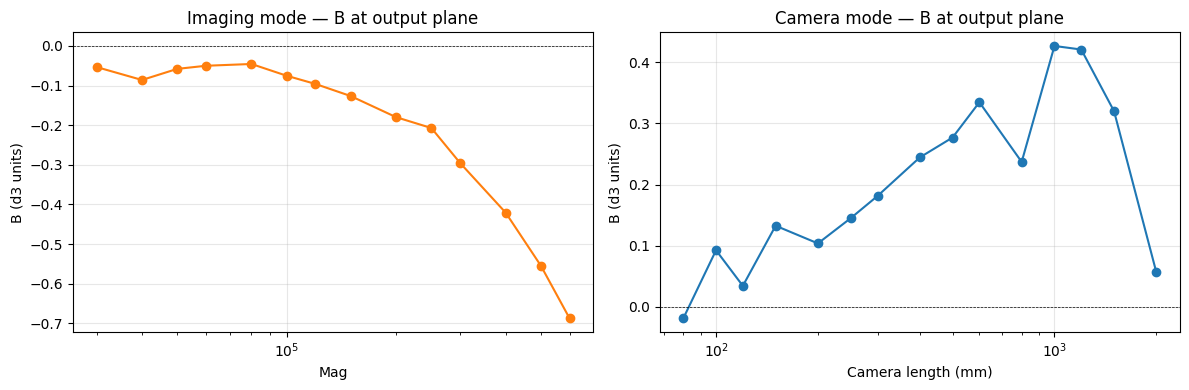

In [42]:
# ── B values at the output plane (after d4) for every operating point ─
# If the imaging condition is perfectly satisfied, B = 0.
# Non-zero B means the intermediate image is defocused at this plane.

print("B values at fitted reference operating points")
print("=" * 72)

# --- Imaging mode ---
print(f"\n{'Mag':>8s}  {'A (fit)':>12s}  {'A (target)':>12s}  {'B':>12s}  {'B/dtot':>10s}")
print("-" * 62)
dtot_img = d1i_f + d2_f + 1.0 + d4_f
for j in range(len(mags_ref)):
    phi = alpha_f * x_img[:, j]**2
    a = A_poly(d_img_f, phi)
    b = B_poly(d_img_f, phi)
    mt = si_best * s_img_f * mags_ref[j]
    print(f"{mags_ref[j]:>8.0f}  {a:>12.6f}  {mt:>12.6f}  {b:>12.6f}  {b/dtot_img:>10.6f}")

b_img = np.array([B_poly(d_img_f, alpha_f * x_img[:, j]**2) for j in range(len(mags_ref))])
print(f"\n  B range (imaging):  [{b_img.min():.6f}, {b_img.max():.6f}]")
print(f"  |B| max = {np.abs(b_img).max():.6f} d3 = {np.abs(b_img).max() * D3_MM:.3f} mm")

# --- Camera mode ---
print(f"\n{'CL (mm)':>8s}  {'A (fit)':>12s}  {'A (target)':>12s}  {'B':>12s}  {'B/dtot':>10s}")
print("-" * 62)
dtot_cam = d1c_f + d2_f + 1.0 + d4_f
for j in range(len(cl_ref)):
    phi = alpha_f * x_cam[:, j]**2
    a = A_poly(d_cam_f, phi)
    b = B_poly(d_cam_f, phi)
    mt = sc_best * s_cam_f * cl_ref[j]
    print(f"{cl_ref[j]:>8.0f}  {a:>12.6f}  {mt:>12.6f}  {b:>12.6f}  {b/dtot_cam:>10.6f}")

b_cam = np.array([B_poly(d_cam_f, alpha_f * x_cam[:, j]**2) for j in range(len(cl_ref))])
print(f"\n  B range (camera):   [{b_cam.min():.6f}, {b_cam.max():.6f}]")
print(f"  |B| max = {np.abs(b_cam).max():.6f} d3 = {np.abs(b_cam).max() * D3_MM:.3f} mm")

# --- Plot B vs mag ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mags_ref, b_img, 'o-', color='C1')
axes[0].axhline(0, color='k', ls='--', lw=0.5)
axes[0].set_xlabel('Mag'); axes[0].set_ylabel('B (d3 units)')
axes[0].set_title('Imaging mode — B at output plane')
axes[0].set_xscale('log'); axes[0].grid(True, alpha=0.3)

axes[1].plot(cl_ref, b_cam, 'o-', color='C0')
axes[1].axhline(0, color='k', ls='--', lw=0.5)
axes[1].set_xlabel('Camera length (mm)'); axes[1].set_ylabel('B (d3 units)')
axes[1].set_title('Camera mode — B at output plane')
axes[1].set_xscale('log'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Hard-B=0 fit: 9 parameters, B=0 enforced analytically ...
Done in 43.1s  |  signs=(+1,+1)  w_img=1.0  cost=0.010745
  (thin-lens soft-B cost was 0.456403)

Hard-B distances (d3=1=62.5 mm):
  d1_img  = 0.2002  (was 0.2112, CAD 0.200)
  d1_cam  = 3.1890  (was 2.1723, CAD 3.200)
  d2      = 1.2323  (was 1.1870, CAD 1.233)
  d4      = 0.8333  (was 0.8323, CAD 0.833)
  alpha   = [13.5332, 17.0861, 6.6616]  (was [13.1786, 15.6901, 6.6768])
  s_img   = 1.4710e-04   →  M_obj·M_proj = 6798.1
  s_cam   = 4.3879e-03   →  f_obj = 2.279 mm

B at DATA operating points (α·x² with hard-B fitted params):
  Imaging: [-0.990416, -0.062075]  |B|_max = 0.9904
  Camera:  [0.726602, 21.749934]  |B|_max = 21.7499
  (thin was: img 0.6878, cam 0.4270)

────────────────────────────────────────────────────────────────────────
Implied DAC (from B=0+A=m) vs actual DAC:

     Mag  x1_data  x1_imp     Δx1  x2_data  x2_imp     Δx2
------------------------------------------------------------
   30000  0.6216  0.6441  +

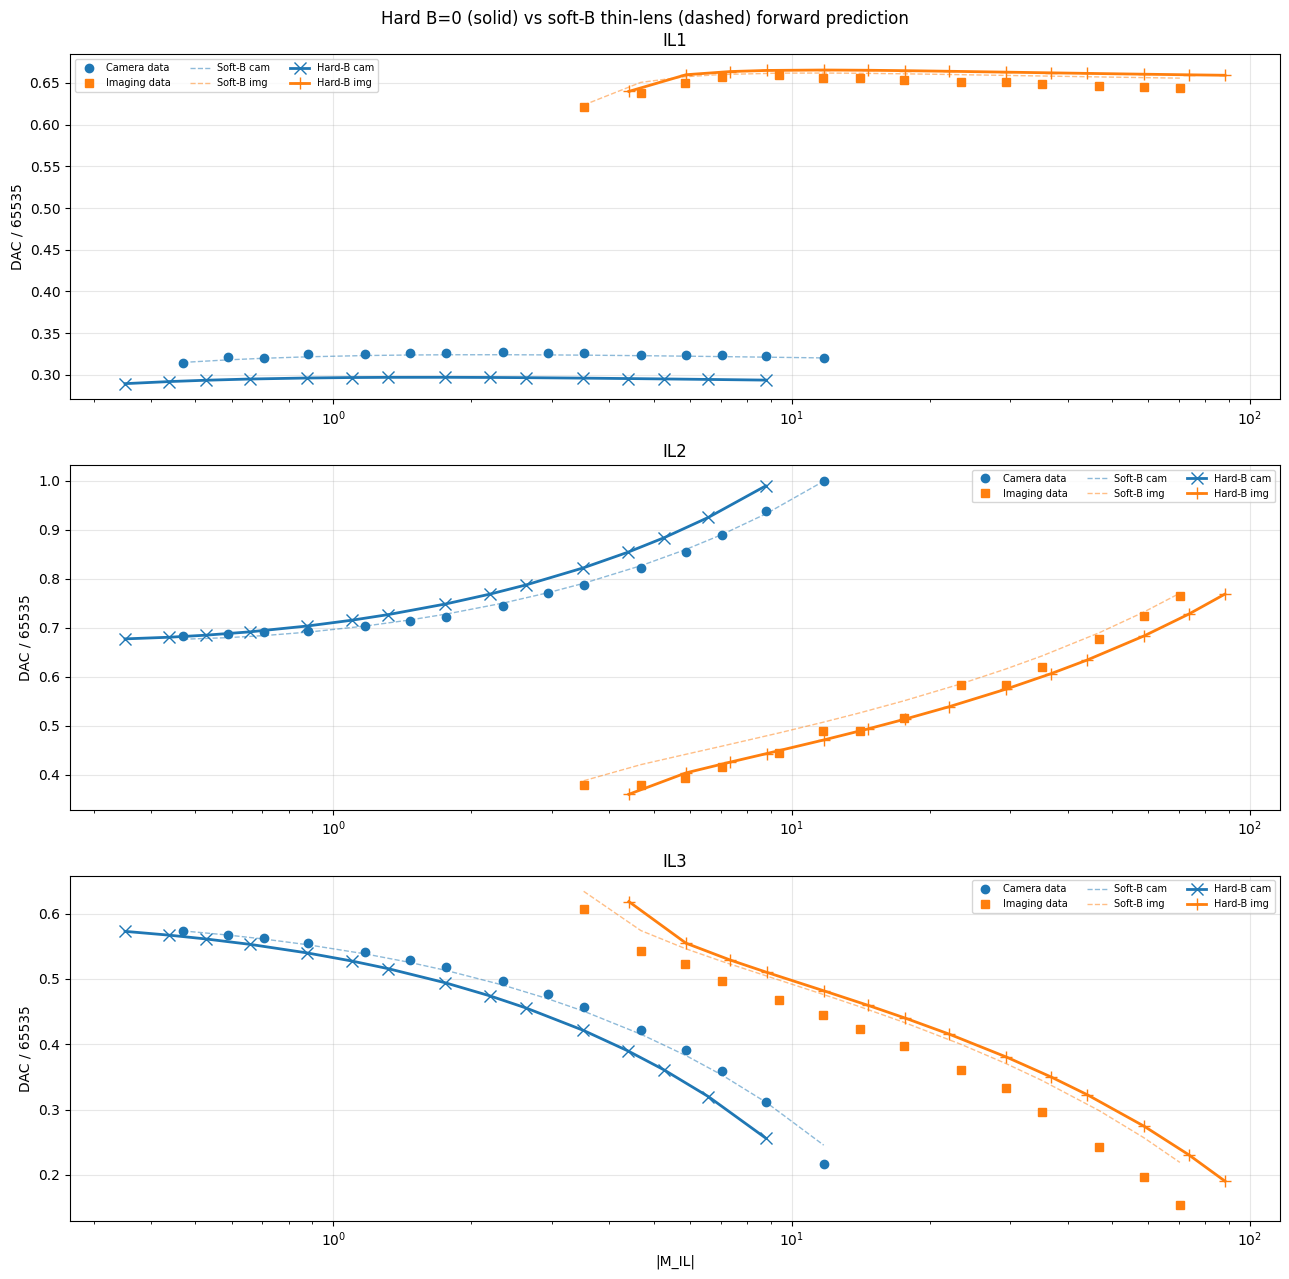


RMSE comparison (forward vs data):
  Lens    Soft img    Hard img    Soft cam    Hard cam
  ----------------------------------------------------
   IL1     0.00835     0.01321     0.00222     0.02861
   IL2     0.02956     0.01980     0.00466     0.00574
   IL3     0.04127     0.02136     0.00884     0.01059

  Overall RMSE:  soft-B = 0.02107   hard-B = 0.01819


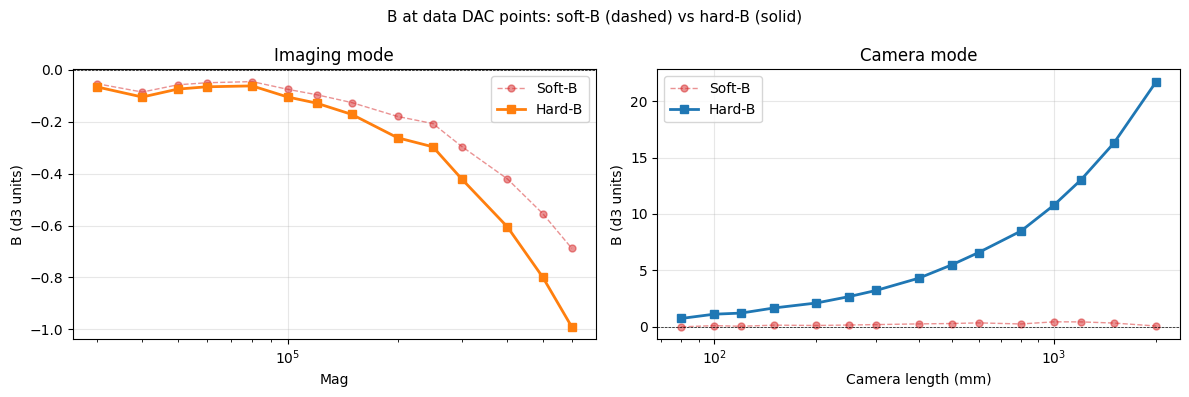

In [44]:
# ══════════════════════════════════════════════════════════════════════
# HARD B=0 MODEL
# ══════════════════════════════════════════════════════════════════════
# Instead of fitting A and B residuals simultaneously,
# analytically enforce B=0 and A=m for every operating point.
#
# For each point j with known DAC (x1j, x2j, x3j) and target m:
#   φ3 = α3·x3j²
#   φ2* = phi2_exact(φ3, m, d)   ← from combined B=0 + A=m elimination
#   φ1* = phi1_exact(φ2*, φ3, m, d) ← from A=m
#
# φ1* and φ2* exactly satisfy B=0 and A=m by construction.
# The residuals measure how well the power law predicts these:
#   x1_implied = √(φ1*/α1),  x2_implied = √(φ2*/α2)
#   residual = (x_implied - x_data)
#
# Same 9 parameters: d1i, d1c, d2, d4, log(α1..3), log(s_i), log(s_c)

def make_hardB_residual_fn(si, sc, w_img=1.0):
    """Residuals with B=0 and A=m enforced analytically."""
    def fn(p):
        d1i, d1c, d2, d4 = p[:4]
        alpha = np.exp(p[4:7])
        s_i, s_c = np.exp(p[7]), np.exp(p[8])
        d_i = np.array([d1i, d2, 1.0, d4])
        d_c = np.array([d1c, d2, 1.0, d4])
        res = []
        # Imaging mode
        for j in range(len(mags_ref)):
            m = si * s_i * mags_ref[j]
            p3 = alpha[2] * x_img[2, j]**2
            p2star = phi2_exact(p3, m, d_i)
            if (not np.isfinite(p2star)) or p2star <= 0:
                res.extend([w_img * 1.0, w_img * 1.0])  # penalty
                continue
            p1star = phi1_exact(p2star, p3, m, d_i)
            if (not np.isfinite(p1star)) or p1star <= 0:
                res.extend([w_img * 1.0, w_img * 1.0])
                continue
            x1_imp = np.sqrt(p1star / alpha[0])
            x2_imp = np.sqrt(p2star / alpha[1])
            res.append(w_img * (x1_imp - x_img[0, j]))
            res.append(w_img * (x2_imp - x_img[1, j]))
        # Camera mode
        for j in range(len(cl_ref)):
            m = sc * s_c * cl_ref[j]
            p3 = alpha[2] * x_cam[2, j]**2
            p2star = phi2_exact(p3, m, d_c)
            if (not np.isfinite(p2star)) or p2star <= 0:
                res.extend([1.0, 1.0])
                continue
            p1star = phi1_exact(p2star, p3, m, d_c)
            if (not np.isfinite(p1star)) or p1star <= 0:
                res.extend([1.0, 1.0])
                continue
            x1_imp = np.sqrt(p1star / alpha[0])
            x2_imp = np.sqrt(p2star / alpha[1])
            res.append(x1_imp - x_cam[0, j])
            res.append(x2_imp - x_cam[1, j])
        # CAD priors (same as thin-lens)
        res.append(W_CAD       * (d2  - CAD_D2)  / (CAD_SIGMA * CAD_D2))
        res.append(W_CAD       * (d4  - CAD_D4)  / (CAD_SIGMA * CAD_D4))
        res.append(W_CAD       * (d1i - CAD_D1I) / (CAD_SIGMA * CAD_D1I))
        res.append(W_CAD / 3.0 * (d1c - CAD_D1C) / (CAD_SIGMA * CAD_D1C))
        # f_obj soft prior
        f_obj_mm = 1.0 / (abs(M_PROJ) * s_c)
        res.append(W_FOBJ * max(0.0, F_OBJ_MIN_MM - f_obj_mm))
        res.append(W_FOBJ * max(0.0, f_obj_mm - F_OBJ_MAX_MM))
        return np.array(res)
    return fn

# Same bounds as thin-lens (9 params)
print("Hard-B=0 fit: 9 parameters, B=0 enforced analytically ...")
t0 = time.perf_counter()

best_hb, cost_hb, signs_hb, wimg_hb = None, np.inf, None, None

for si in [+1, -1]:
    for sc in [+1, -1]:
        for w_img in W_IMG_VALS:
            fn = make_hardB_residual_fn(si, sc, w_img=w_img)
            for p0 in init_guesses:
                for meth in ['trf', 'dogbox']:
                    try:
                        res = least_squares(fn, p0, bounds=(lb, ub), method=meth,
                                            max_nfev=20000, verbose=0, diff_step=0.001)
                        if res.cost < cost_hb:
                            cost_hb, best_hb = res.cost, res
                            signs_hb, wimg_hb = (si, sc), w_img
                    except Exception:
                        pass

# Warm-start refinement
if best_hb is not None:
    for w_img in W_IMG_VALS:
        fn = make_hardB_residual_fn(*signs_hb, w_img=w_img)
        for meth in ['trf', 'dogbox']:
            try:
                res = least_squares(fn, best_hb.x, bounds=(lb, ub), method=meth,
                                    max_nfev=100000, verbose=0, diff_step=1e-4,
                                    ftol=1e-15, xtol=1e-15, gtol=1e-15)
                if res.cost < cost_hb:
                    cost_hb, best_hb = res.cost, res
                    wimg_hb = w_img
            except Exception:
                pass

t_hb = time.perf_counter() - t0
si_hb, sc_hb = signs_hb
print(f"Done in {t_hb:.1f}s  |  signs=({si_hb:+d},{sc_hb:+d})  w_img={wimg_hb}  cost={cost_hb:.6f}")
print(f"  (thin-lens soft-B cost was {best_cost:.6f})")

# Extract parameters
d1i_hb, d1c_hb, d2_hb, d4_hb = best_hb.x[:4]
alpha_hb = np.exp(best_hb.x[4:7])
s_img_hb, s_cam_hb = np.exp(best_hb.x[7]), np.exp(best_hb.x[8])
d_img_hb = np.array([d1i_hb, d2_hb, 1.0, d4_hb])
d_cam_hb = np.array([d1c_hb, d2_hb, 1.0, d4_hb])
m_img_hb = s_img_hb * mags_ref
m_cam_hb = s_cam_hb * cl_ref
f_obj_hb_mm = 1.0 / (abs(M_PROJ) * s_cam_hb)

print(f"\nHard-B distances (d3=1={_d3_mm:.1f} mm):")
for nm, fit_hb, fit_old, cad in [('d1_img', d1i_hb, d1i_f, CAD_D1I),
                                  ('d1_cam', d1c_hb, d1c_f, CAD_D1C),
                                  ('d2', d2_hb, d2_f, CAD_D2),
                                  ('d4', d4_hb, d4_f, CAD_D4)]:
    print(f"  {nm:7s} = {fit_hb:.4f}  (was {fit_old:.4f}, CAD {cad:.3f})")
print(f"  alpha   = [{alpha_hb[0]:.4f}, {alpha_hb[1]:.4f}, {alpha_hb[2]:.4f}]"
      f"  (was [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}])")
print(f"  s_img   = {s_img_hb:.4e}   →  M_obj·M_proj = {1/s_img_hb:.1f}")
print(f"  s_cam   = {s_cam_hb:.4e}   →  f_obj = {f_obj_hb_mm:.3f} mm")

# ── B values: should be ≈ 0 by construction at the IMPLIED operating point
#    But let's check at the ACTUAL DAC data (using the fitted α·x²) ─────

b_img_hb = np.array([B_poly(d_img_hb, alpha_hb * x_img[:, j]**2)
                      for j in range(len(mags_ref))])
b_cam_hb = np.array([B_poly(d_cam_hb, alpha_hb * x_cam[:, j]**2)
                      for j in range(len(cl_ref))])

print(f"\nB at DATA operating points (α·x² with hard-B fitted params):")
print(f"  Imaging: [{b_img_hb.min():.6f}, {b_img_hb.max():.6f}]  "
      f"|B|_max = {np.abs(b_img_hb).max():.4f}")
print(f"  Camera:  [{b_cam_hb.min():.6f}, {b_cam_hb.max():.6f}]  "
      f"|B|_max = {np.abs(b_cam_hb).max():.4f}")
print(f"  (thin was: img {np.abs(b_img).max():.4f}, cam {np.abs(b_cam).max():.4f})")

# ── Implied vs actual DAC comparison ─────────────────────────────────

print(f"\n{'─'*72}")
print("Implied DAC (from B=0+A=m) vs actual DAC:")
print(f"\n{'Mag':>8s}  {'x1_data':>7s} {'x1_imp':>7s} {'Δx1':>7s}  "
      f"{'x2_data':>7s} {'x2_imp':>7s} {'Δx2':>7s}")
print("-" * 60)
x1_imp_img, x2_imp_img = [], []
for j in range(len(mags_ref)):
    m = si_hb * s_img_hb * mags_ref[j]
    p3 = alpha_hb[2] * x_img[2, j]**2
    p2s = phi2_exact(p3, m, d_img_hb)
    p1s = phi1_exact(p2s, p3, m, d_img_hb)
    x1i = np.sqrt(max(p1s, 0) / alpha_hb[0]) if (np.isfinite(p1s) and p1s > 0) else np.nan
    x2i = np.sqrt(max(p2s, 0) / alpha_hb[1]) if (np.isfinite(p2s) and p2s > 0) else np.nan
    x1_imp_img.append(x1i); x2_imp_img.append(x2i)
    print(f"{mags_ref[j]:>8.0f}  {x_img[0,j]:.4f}  {x1i:.4f}  {x1i-x_img[0,j]:+.4f}  "
          f"{x_img[1,j]:.4f}  {x2i:.4f}  {x2i-x_img[1,j]:+.4f}")

print(f"\n{'CL mm':>8s}  {'x1_data':>7s} {'x1_imp':>7s} {'Δx1':>7s}  "
      f"{'x2_data':>7s} {'x2_imp':>7s} {'Δx2':>7s}")
print("-" * 60)
x1_imp_cam, x2_imp_cam = [], []
for j in range(len(cl_ref)):
    m = sc_hb * s_cam_hb * cl_ref[j]
    p3 = alpha_hb[2] * x_cam[2, j]**2
    p2s = phi2_exact(p3, m, d_cam_hb)
    p1s = phi1_exact(p2s, p3, m, d_cam_hb)
    x1i = np.sqrt(max(p1s, 0) / alpha_hb[0]) if (np.isfinite(p1s) and p1s > 0) else np.nan
    x2i = np.sqrt(max(p2s, 0) / alpha_hb[1]) if (np.isfinite(p2s) and p2s > 0) else np.nan
    x1_imp_cam.append(x1i); x2_imp_cam.append(x2i)
    print(f"{cl_ref[j]:>8.0f}  {x_cam[0,j]:.4f}  {x1i:.4f}  {x1i-x_cam[0,j]:+.4f}  "
          f"{x_cam[1,j]:.4f}  {x2i:.4f}  {x2i-x_cam[1,j]:+.4f}")

x1_imp_img, x2_imp_img = np.array(x1_imp_img), np.array(x2_imp_img)
x1_imp_cam, x2_imp_cam = np.array(x1_imp_cam), np.array(x2_imp_cam)

# ── Forward prediction using the hard-B parameters ──────────────────
# Re-use the existing thin-lens forward solver with the new parameters

r_img_hb_vals = x_img[0] + x_img[1] + x_img[2]
r_cam_hb_vals = x_cam[0] + x_cam[1] + x_cam[2]

r_img_hb, pi_hb, sc_img_hb = choose_r_target(
    m_img_hb, d_img_hb, alpha_hb, r_img_hb_vals, si_hb, x_img, force_first=False)
r_cam_hb, pc_hb, sc_cam_hb = choose_r_target(
    m_cam_hb, d_cam_hb, alpha_hb, r_cam_hb_vals, sc_hb, x_cam, force_first=False)

n_img_ok_hb = np.sum(np.isfinite(pi_hb[0]))
n_cam_ok_hb = np.sum(np.isfinite(pc_hb[0]))
print(f"\nForward prediction (hard-B params):")
print(f"  r_img = {r_img_hb:.4f}  |  r_cam = {r_cam_hb:.4f}")
print(f"  Solved: imaging {n_img_ok_hb}/{len(m_img_hb)}, camera {n_cam_ok_hb}/{len(m_cam_hb)}")

# ── Plot: hard-B vs thin-lens vs data ────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 13))
fig.suptitle('Hard B=0 (solid) vs soft-B thin-lens (dashed) forward prediction', fontsize=12)

lenses_hb = [
    ('IL1', x1_ref, pi_hb[0], pi_f[0], x1_cl_ref, pc_hb[0], pc_f[0]),
    ('IL2', x2_ref, pi_hb[1], pi_f[1], x2_cl_ref, pc_hb[1], pc_f[1]),
    ('IL3', x3_ref, pi_hb[2], pi_f[2], x3_cl_ref, pc_hb[2], pc_f[2]),
]
for ax, (nm, yi_r, yi_hb, yi_old, yc_r, yc_hb, yc_old) in zip(axes, lenses_hb):
    ax.plot(m_cam, yc_r, 'o', color='C0', ms=6, label='Camera data')
    ax.plot(m_img, yi_r, 's', color='C1', ms=6, label='Imaging data')
    mc_old = np.isfinite(yc_old)
    if np.any(mc_old): ax.plot(m_cam[mc_old], yc_old[mc_old], '--', color='C0', lw=1, alpha=0.5, label='Soft-B cam')
    mi_old = np.isfinite(yi_old)
    if np.any(mi_old): ax.plot(m_img[mi_old], yi_old[mi_old], '--', color='C1', lw=1, alpha=0.5, label='Soft-B img')
    mc_hb = np.isfinite(yc_hb)
    if np.any(mc_hb): ax.plot(m_cam_hb[mc_hb], yc_hb[mc_hb], 'x-', color='C0', lw=2, ms=8, label='Hard-B cam')
    mi_hb = np.isfinite(yi_hb)
    if np.any(mi_hb): ax.plot(m_img_hb[mi_hb], yi_hb[mi_hb], '+-', color='C1', lw=2, ms=8, label='Hard-B img')
    ax.set_xscale('log'); ax.set_ylabel('DAC / 65535'); ax.set_title(nm)
    ax.grid(True, alpha=0.3); ax.legend(ncol=3, fontsize=7)
axes[-1].set_xlabel('|M_IL|')
plt.tight_layout(); plt.show()

# ── RMSE comparison ──────────────────────────────────────────────────

print("\nRMSE comparison (forward vs data):")
print(f"  {'Lens':>4s}  {'Soft img':>10s}  {'Hard img':>10s}  {'Soft cam':>10s}  {'Hard cam':>10s}")
print("  " + "-" * 52)
all_errs_hb = []
for (nm, yi_r, yi_hb, yi_old, yc_r, yc_hb, yc_old) in lenses_hb:
    mi_old = np.isfinite(yi_old)
    mi_hb  = np.isfinite(yi_hb)
    mc_old = np.isfinite(yc_old)
    mc_hb  = np.isfinite(yc_hb)
    ri_old = np.sqrt(np.mean((yi_old[mi_old]-yi_r[mi_old])**2)) if np.any(mi_old) else np.nan
    ri_hb  = np.sqrt(np.mean((yi_hb[mi_hb]-yi_r[mi_hb])**2))   if np.any(mi_hb)  else np.nan
    rc_old = np.sqrt(np.mean((yc_old[mc_old]-yc_r[mc_old])**2)) if np.any(mc_old) else np.nan
    rc_hb  = np.sqrt(np.mean((yc_hb[mc_hb]-yc_r[mc_hb])**2))   if np.any(mc_hb)  else np.nan
    print(f"  {nm:>4s}  {ri_old:>10.5f}  {ri_hb:>10.5f}  {rc_old:>10.5f}  {rc_hb:>10.5f}")
    if np.any(mi_hb): all_errs_hb.append((yi_hb[mi_hb]-yi_r[mi_hb])**2)
    if np.any(mc_hb): all_errs_hb.append((yc_hb[mc_hb]-yc_r[mc_hb])**2)

if all_errs_hb:
    overall_hb = np.sqrt(np.mean(np.concatenate(all_errs_hb)))
    overall_old = np.sqrt(np.mean(np.concatenate(all_errs))) if all_errs else np.nan
    print(f"\n  Overall RMSE:  soft-B = {overall_old:.5f}   hard-B = {overall_hb:.5f}")

# ── B-value comparison ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('B at data DAC points: soft-B (dashed) vs hard-B (solid)', fontsize=11)
axes[0].plot(mags_ref, b_img, 'o--', color='C3', lw=1, ms=5, alpha=0.5, label='Soft-B')
axes[0].plot(mags_ref, b_img_hb, 's-', color='C1', lw=2, ms=6, label='Hard-B')
axes[0].axhline(0, color='k', ls='--', lw=0.5)
axes[0].set_xlabel('Mag'); axes[0].set_ylabel('B (d3 units)')
axes[0].set_title('Imaging mode'); axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(cl_ref, b_cam, 'o--', color='C3', lw=1, ms=5, alpha=0.5, label='Soft-B')
axes[1].plot(cl_ref, b_cam_hb, 's-', color='C0', lw=2, ms=6, label='Hard-B')
axes[1].axhline(0, color='k', ls='--', lw=0.5)
axes[1].set_xlabel('Camera length (mm)'); axes[1].set_ylabel('B (d3 units)')
axes[1].set_title('Camera mode'); axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

In [46]:
# ── Verify: B at the *implied* operating points (should be machine-zero) ──

print("B at IMPLIED powers (φ1*, φ2* from B=0+A=m, φ3 = α3·x3_data²)")
print("=" * 72)

print(f"\n{'Mag':>8s}  {'φ1*':>8s}  {'φ2*':>8s}  {'φ3':>8s}  {'B(implied)':>12s}  {'A(implied)':>12s}  {'A(target)':>12s}")
print("-" * 80)
for j in range(len(mags_ref)):
    m = si_hb * s_img_hb * mags_ref[j]
    p3 = alpha_hb[2] * x_img[2, j]**2
    p2s = phi2_exact(p3, m, d_img_hb)
    p1s = phi1_exact(p2s, p3, m, d_img_hb)
    phi_imp = np.array([p1s, p2s, p3])
    b_imp = B_poly(d_img_hb, phi_imp)
    a_imp = A_poly(d_img_hb, phi_imp)
    print(f"{mags_ref[j]:>8.0f}  {p1s:>8.4f}  {p2s:>8.4f}  {p3:>8.4f}  {b_imp:>12.2e}  {a_imp:>12.6f}  {m:>12.6f}")

print(f"\n{'CL mm':>8s}  {'φ1*':>8s}  {'φ2*':>8s}  {'φ3':>8s}  {'B(implied)':>12s}  {'A(implied)':>12s}  {'A(target)':>12s}")
print("-" * 80)
for j in range(len(cl_ref)):
    m = sc_hb * s_cam_hb * cl_ref[j]
    p3 = alpha_hb[2] * x_cam[2, j]**2
    p2s = phi2_exact(p3, m, d_cam_hb)
    p1s = phi1_exact(p2s, p3, m, d_cam_hb)
    phi_imp = np.array([p1s, p2s, p3])
    b_imp = B_poly(d_cam_hb, phi_imp)
    a_imp = A_poly(d_cam_hb, phi_imp)
    print(f"{cl_ref[j]:>8.0f}  {p1s:>8.4f}  {p2s:>8.4f}  {p3:>8.4f}  {b_imp:>12.2e}  {a_imp:>12.6f}  {m:>12.6f}")

B at IMPLIED powers (φ1*, φ2* from B=0+A=m, φ3 = α3·x3_data²)

     Mag       φ1*       φ2*        φ3    B(implied)    A(implied)     A(target)
--------------------------------------------------------------------------------
   30000    5.6152    2.3724    2.4487      8.88e-16      4.412990      4.412990
   40000    5.9434    2.4243    1.9596     -8.88e-16      5.883986      5.883986
   50000    5.9811    2.9465    1.8175      0.00e+00      7.354983      7.354983
   60000    6.0165    3.1188    1.6485     -8.88e-16      8.825979      8.825979
   80000    6.0180    3.5595    1.4594     -2.66e-15     11.767972     11.767972
  100000    6.0071    3.9382    1.3215      0.00e+00     14.709965     14.709965
  120000    5.9974    4.2451    1.1966      0.00e+00     17.651959     17.651959
  150000    5.9806    4.6969    1.0555     -2.66e-15     22.064948     22.064948
  200000    5.9586    5.3616    0.8658     -3.55e-15     29.419931     29.419931
  250000    5.9398    6.0303    0.7373      0.